In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from cellosaurus_utils import get_cell_line_cellosaurus_annotations, features_dir
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram
import petab.v1 as petab

brca_df, seqvar_df = get_cell_line_cellosaurus_annotations(file_dir=features_dir)

File 'cellosaurus.txt' already exists in /Users/frohlif/Documents/projects/DeepMechanisticModels/features. Skipping download.


In [5]:
seqvar_df = seqvar_df[['KRAS_M', 'MAP2K4_M', 'PIK3CA_M', 'MAPK1_M', 'MAP2K4_D', 'BRAF_M', 'PTEN_D', 'HRAS_M']]

In [6]:
def nan_euclidean(u, v):
    mask = np.isfinite(u) & np.isfinite(v)
    if np.sum(mask) == 0:
        return np.nan  # Or a large constant like 1e6
    return np.mean(np.square(u[mask] - v[mask]))

In [7]:
import synapseclient
syn = synapseclient.Synapse()
syn.login()

file_id_table = pd.read_csv(syn.get('syn20631269').path, index_col=0).set_index('fileID')

Welcome, Fabian Froehlich!

[syn20631269:FileID_table.csv]: Found existing file at /Users/frohlif/.synapseCache/298/42318298/FileID_table.csv, skipping download.


In [8]:
markers =(
    # RTKS
    'EGFR', 'ERBB2', 'ERBB3', 'ERBB4',
    # 'MET', 'INSR', 'NRTK', 'MERTK', # https://breast-cancer-research.biomedcentral.com/articles/10.1186/s13058-019-1127-y
    # 'FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'FGFR1', # FGFR
    # 'EPHA1', 'EPHA2', 'EPHA3', 'EPHA4', 'EPHA5', 'EPHA6', 'EPHA7', 'EPHA8', 'EPHA9', 'EPHA10', # EPHA
    # 'PDGFRA', 'PDGFRB'
    # LIGANDS
    # 'EGF', 'TGFA', 'AREG', 'BTC', 'HBEGF', 'EREG', 'NRG1', 'NRG2', 'NRG3', 'NRG4',
    # 'FGF1', 'FGF2', 'FGF3', 'FGF4', 'FGF5', 'FGF6', 'FGF7', 'FGF8', 'FGF9', 'FGF10', 'FGF11', 'FGF12'
)

In [9]:
df_proteomics = pd.read_csv(f'./data/proteomics.csv', index_col=0)
df_proteomics = df_proteomics[df_proteomics['FEATURE_ID'].isin(markers)]
df_transcriptomics = pd.read_csv(f'./data/transcriptomics.csv', index_col=0)
df_transcriptomics = df_transcriptomics[df_transcriptomics['FEATURE_ID'].isin(markers)]

In [10]:
from scipy.stats import zscore
from functools import partial

dftrans = df_transcriptomics.pivot_table(index=petab.PREEQUILIBRATION_CONDITION_ID, values=petab.MEASUREMENT, columns='FEATURE_ID').apply(partial(zscore, nan_policy='omit'))
dfprot = df_proteomics.pivot_table(index=petab.PREEQUILIBRATION_CONDITION_ID, values=petab.MEASUREMENT, columns='FEATURE_ID').apply(partial(zscore, nan_policy='omit'))

In [15]:
def plot_residuals(model, context):
    df = pd.read_csv(f'./eval/{model}/dream_cytof/by_cl_cond_obs.csv', index_col=0)
    df = df[np.isfinite(df.rmse)]
    df = df[df.context == context]

    dfp = pd.pivot_table(df, index='sample', columns=['condition', 'observable', 'samples', 'ref'], values='rmse')
    dfp_dmm = dfp.loc[:, dfp.columns.get_level_values('ref') == 'DMM'].copy()
    dfp_dmm = dfp_dmm.loc[dfp_dmm.max(axis=1) > 0.8, :]
    annotations = pd.DataFrame(
        {
            key: [file_id_table[file_id_table.cell_line == cell[1:]][key].values[0] for cell in dfp_dmm.index]
            for key in ('PAM50', 'Neve', 'HER2',)
        },
        index=dfp_dmm.index
    )
    annotations = pd.get_dummies(annotations)

    distance_matrix = pdist(dfp_dmm.values, metric=nan_euclidean)
    linkage_matrix = linkage(distance_matrix, method='centroid')
    d = dendrogram(linkage_matrix, labels=dfp_dmm.index.tolist())

    fig = plt.figure(figsize=(20, 9))
    n_cols = 9
    gs = gridspec.GridSpec(1, n_cols, width_ratios=[1]*4 + [0.02,  0.3, 0.3, 0.02, 0.5])  # Narrower last one

    axes = [fig.add_subplot(gs[i]) for i in range(n_cols)]
    for subgroup, ax in zip(
        ['DMM', 'sample', 'avg_model', 'elasticnet'], axes
    ):
        dfs = dfp.loc[:, dfp.columns.get_level_values('ref') == subgroup]
        dfs.columns = dfs.columns.droplevel('ref').droplevel('samples')
        dfs = dfs.loc[d['ivl']] # sort based on dendrogram
        sns.heatmap(dfs, vmin=0.0, vmax=1.5, ax=ax, cbar=(subgroup == 'DMM'), yticklabels=(subgroup == 'DMM'), cbar_ax=axes[4] if (subgroup == 'DMM') else None, xticklabels=1)
        ax.set_title(subgroup)
        xticklabels = ax.get_xticklabels()

        new_labels = []
        for i, label in enumerate(xticklabels):
            if (i - 2) % 5 == 0:
                new_labels.append(label.get_text())
            else:
                new_labels.append("")

        ax.set_xticklabels(new_labels, rotation=90)
        perts = dfs.columns.get_level_values('condition')
        for pert in perts.unique().tolist():
            i = len(perts) - perts.tolist()[::-1].index(pert)
            ax.axvline(x=i, color='white', linestyle='-', linewidth=1)
        if subgroup != 'DMM':
            ax.set_ylabel('')


    sns.heatmap(dftrans.loc[d['ivl']], ax=axes[5], yticklabels=False, cbar=True, cmap='icefire', cbar_ax=axes[7], vmin=-3.0, vmax=3.0)
    axes[5].set_ylabel('')
    sns.heatmap(dfprot.loc[d['ivl']], ax=axes[6], yticklabels=False, cbar=False, cmap='icefire', vmin=-3.0, vmax=3.0)
    axes[6].set_ylabel('')
    #sns.heatmap(annotations.loc[d['ivl']], ax=axes[8], yticklabels=False, cbar=False, cmap='mako')
    #axes[8].set_ylabel('')
    sns.heatmap(seqvar_df.loc[d['ivl']], ax=axes[8], yticklabels=False, cbar=False, cmap='mako')
    axes[8].set_ylabel('')


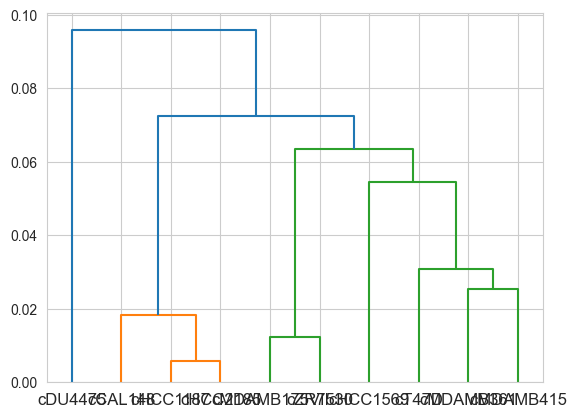

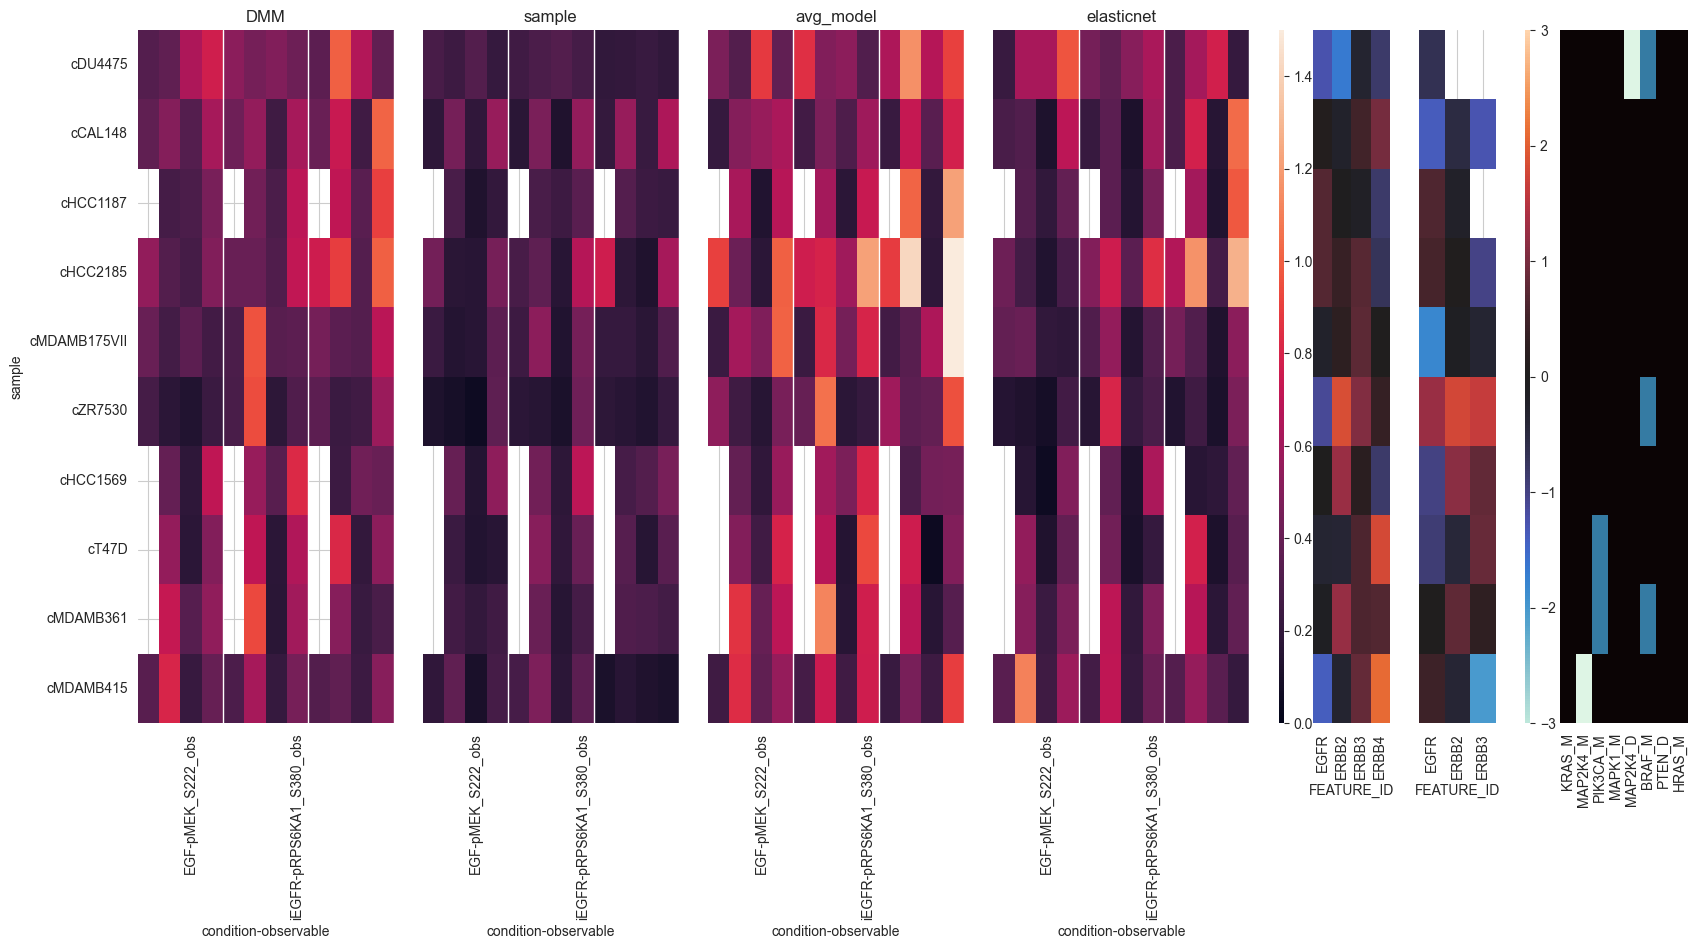

In [14]:
plot_residuals('EGFR_MAPK__logobs', 'cytof_init')

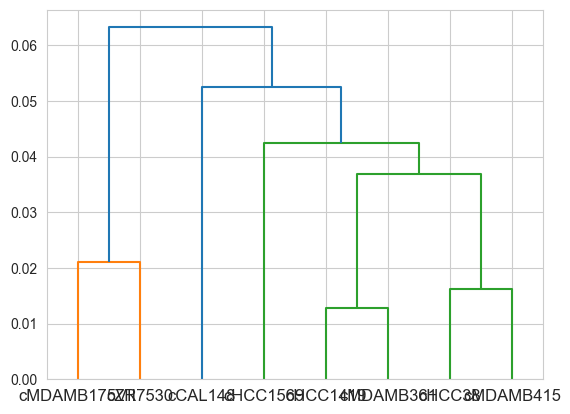

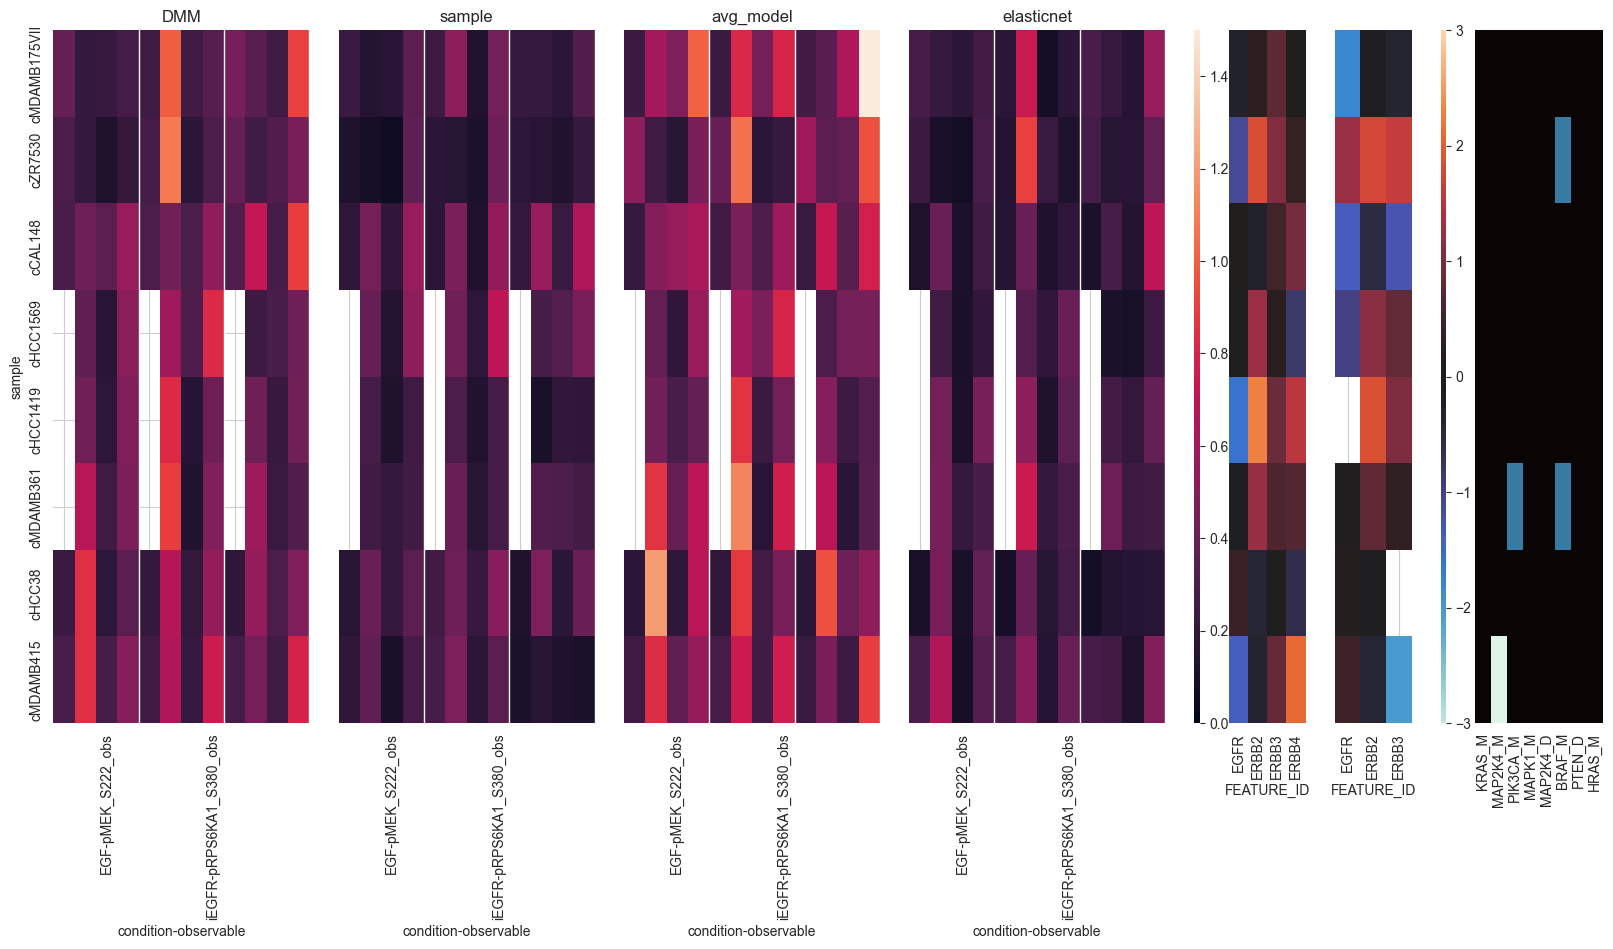

In [16]:
plot_residuals('EGFR_MAPK__logobs', 'cytof_dynamic')

 # analysis EGFR_MAPK__begfr_berbb2_bmek 30.07.2025 (v45)

## HCC2185, CAL148, HCC1187
pERK and pRPS6KA1 do not respond to iMEK


## NOTE HCC2185: outliers in pERBB2 and pRPS6KA1 at 17/18 minutes, not captured by per sample
## NOTE MDAMB415: outliers in pERK and pRPS6KA1 at 0 minutes?

## MDAMB415, MCF7, MDAMB361
- profiles essentially flat, with lower than usual baseline pERK levels
- ever so slight pathway activation for MCF7 in EGF only activation
- pronounced pathway activation in MDAMB361 in EGF and iEGFR conditions

## MDAMB157, MDAMB134VI, T47D
- pERK and RPS6KA1 only respond to MEK inhibition at t0 in MDAMB157
- essentially no response to EGF but strong iMEK sensitivity for pERK and RPS6KA1 in MDAMB134VI (some ms/cvs appear to get that) NOTE: MDAMB134VI HAS KRAS ACTIVATING MUTATION
- underestimated strong signaling activation, missed by some ms

## EFM192A, HCC1419, UACC812, ZR7530
pERK (and pRPS6KA1) respond to iMEK/iEGFR, but not captured by model
### ALL HER2 POSITIVE

### NOTE HDQP1, UACC812, HCC1187: evidence of transient pMEK/pERK/pRPS6KA1 activation only in iEGFR condition
### NOTE HCC1419, UACC3199: drop in pERK/pRPS6KA1 activation after 10 min in iEGFR, for HCC1419 potentially also in EGF and iMEK conditions?

### NOTE: lapatinib inhibits both ERBB2 and EGFR (or something like that (see https://doi.org/10.1158/0008-5472.can-05-1182))

# EGF condition

## HCC2185, BT20, HCC1954
high pERBB2 error in EGF and iMEK conditions -> **EGFR overexpression?**

## 184B5, MCF12A, MDAMB453, HCC38, MDAMB361, MDAMB415, MDAMB157, HCC1500, HCC1937, HCC1806, HS578T, MCF7, EVSAT
high pERK error in EGF condition ???

## DU4475, HCC1395, MPE600, HCC1500, HCC1569
high RPS6KA1 error in EGF condition ???

# iEGFR condition

## HCC1419, UACC812, MDAMB453, MDAMB316, MDAMB415, ZR7530, MDAMB175VII, EFM192A, UACC812, MCF7
high pERK error in iEGFR condition,

## HCC1187, HCC2185, HCC1419, HCC38
high RPS6KA1 error in iEGFR condition -> signaling via p38  **ADD EGFR independent RPS6KA1 activation**

# iMEK condition

## DU4475, HCC2185, MDAMB134VI, HCC1187, MDAMB157, T47D
high pERK error in iMEK condition -> **BRAFV600E mutation** (DU4475)

## DU4475, BT20, HCC1937
high pMEK error in iMEK condition -> **BRAFV600E mutation** (DU4475)

## CAL148, HCC1187, HCC2185, UACC3199, ZR7530, MDAMB175VII
high RPS6KA1 error in iMEK condition -> signaling via p38? **ADD EGFR independent RPS6KA1 activation**


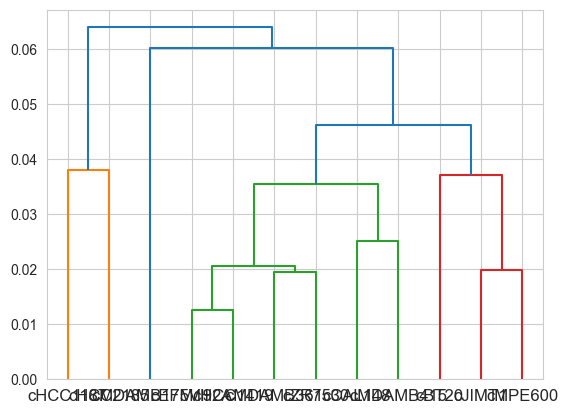

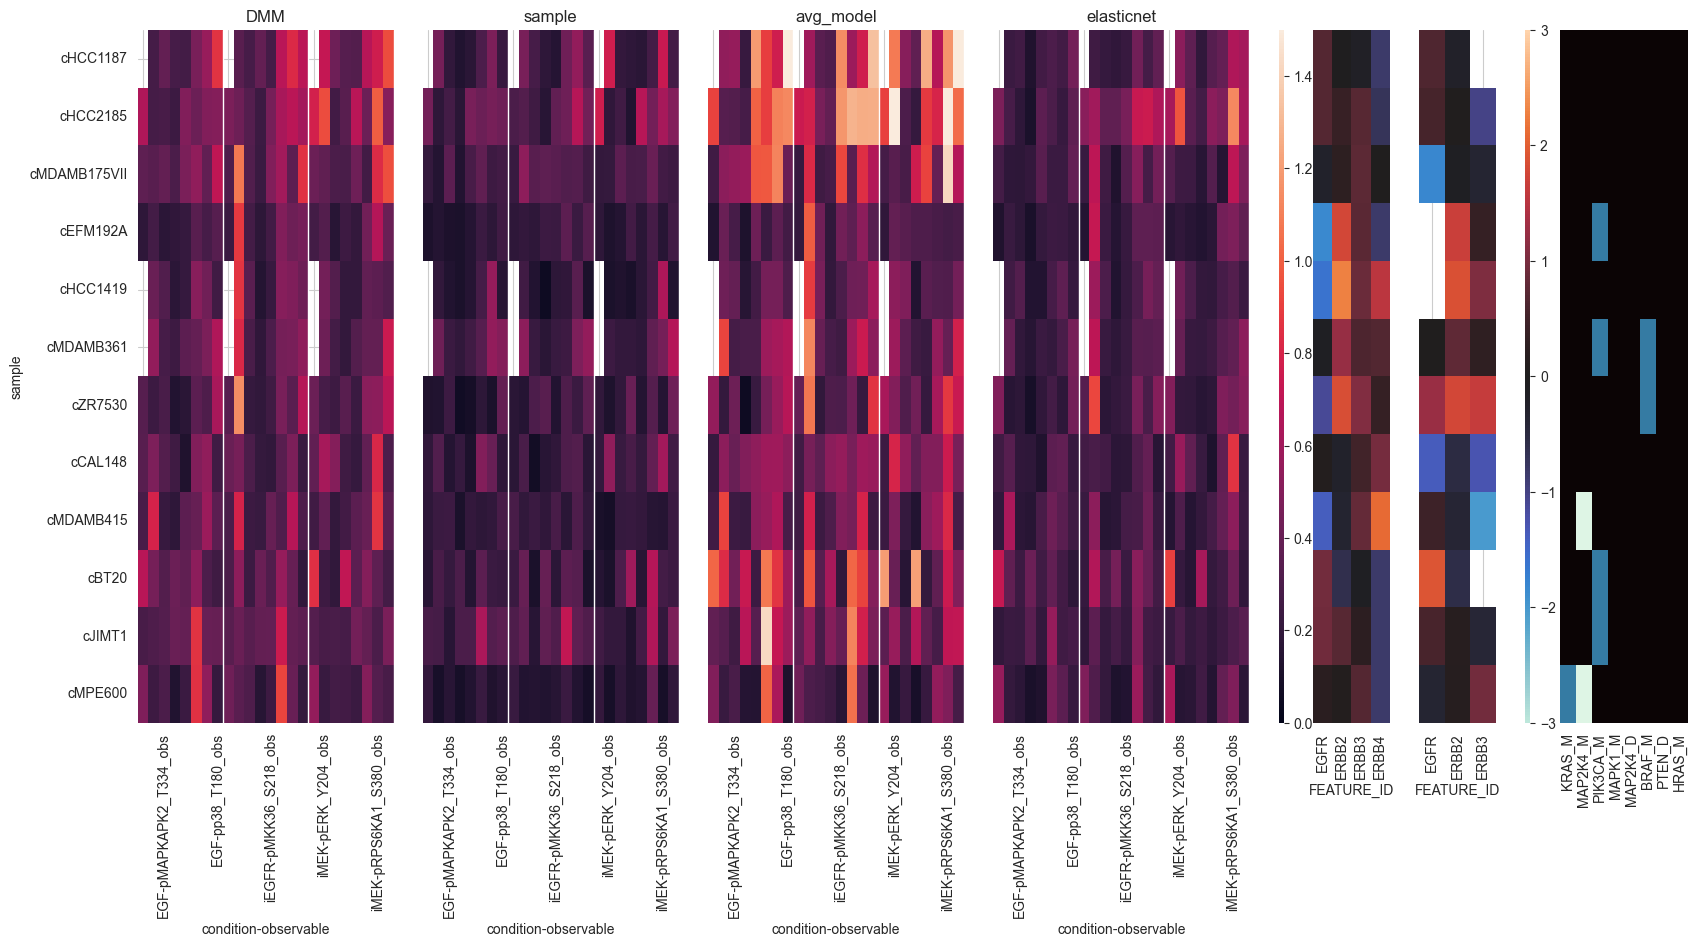

In [39]:
plot_residuals('EGFR_MAPK_P38__logobs')